# Chargement des données d’images

Jusqu’à présent, nous avons travaillé avec des ensembles de données assez artificiels, peu représentatifs des projets réels.  
Dans la pratique, vous serez souvent amené à manipuler des **images de grande taille**, comme celles issues d’appareils photo ou de téléphones portables.  
Dans ce notebook, nous verrons comment **charger des images** et les utiliser pour **entraîner des réseaux de neurones**.

Nous utiliserons un [jeu de données de photos de chats et de chiens](https://www.kaggle.com/c/dogs-vs-cats) disponible sur **Kaggle**.  
Voici quelques exemples d’images :



In [2]:
pip install torch torchvision matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

In [4]:
from torchvision import transforms

# 1. Transformations d'entraînement (Avec Augmentation)
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Transformations de validation/test (Fixes)
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

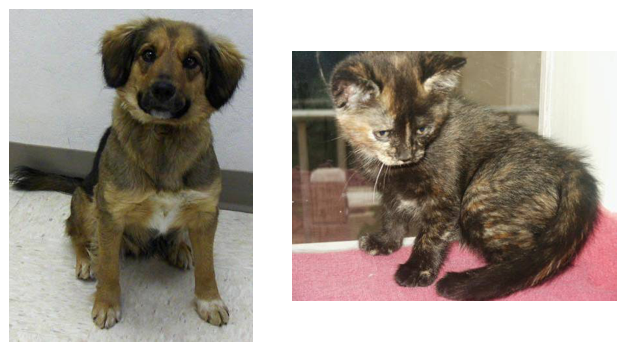

Nous emploierons ce jeu de données pour entraîner un réseau de neurones capable de **distinguer les chats des chiens**.  
Aujourd’hui, cela peut sembler banal, mais il y a encore quelques années, c’était un véritable **défi pour les systèmes de vision par ordinateur**.

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler

# 1. Configuration automatique du répertoire de travail
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
os.chdir(notebook_dir)
print(f"Dossier actuel de travail : {os.getcwd()}")
print(f"Contenu du dossier actuel : {os.listdir('.')}")

# 2. Fixer le Seed pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 3. Détection de la puce graphique
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Reproductibilité activée (Seed {SEED}). Calculs sur : {device}")

# 4. Détection intelligente du dossier de données
possible_dirs = ['Cat_Dog_data', 'Cat_Dog_Data', 'data']
data_dir = None

for d in possible_dirs:
    if os.path.exists(d):
        data_dir = d
        break

if data_dir is None:
    raise FileNotFoundError("ERREUR CRITIQUE : Aucun dossier de données trouvé. "
                            f"Vérifie que ton dossier d'images est bien glissé à l'intérieur de : {os.getcwd()}")

print(f"Dossier de données détecté et sélectionné : '{data_dir}'")

# 5. Transformations d'images
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 6. Chargement initial sécurisé
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=val_test_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_test_transforms)

# 7. Création des indices pour le Split Validation
num_train = len(train_dataset)
indices = list(range(num_train))
split = int(np.floor(0.2 * num_train))

np.random.seed(SEED)
np.random.shuffle(indices)

train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

# 8. Définition des DataLoaders
trainloader = DataLoader(train_dataset, batch_size=64, sampler=train_sampler)
valloader = DataLoader(val_dataset, batch_size=64, sampler=val_sampler)
testloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"\n[SUCCÈS] Données prêtes avec Samplers :")
print(f"-> Images d'entraînement : {len(train_idx)}")
print(f"-> Images de validation : {len(val_idx)}")
print(f"-> Images de test : {len(test_dataset)}")

Dossier actuel de travail : /Users/karifakouyate/Projects/Master IA/Deep_learning/Devoir 2/cnn-catsdogs-KouyateKarifa
Contenu du dossier actuel : ['Cat_Dog_data', '.DS_Store', 'requirements.txt', 'notebook.ipynb', 'best_model_transfer.pth', 'best_model_scratch.pth', 'README.md', '.gitignore', '.git', 'best_model_scratch_sgd.pth']
Reproductibilité activée (Seed 42). Calculs sur : mps
Dossier de données détecté et sélectionné : 'Cat_Dog_data'

[SUCCÈS] Données prêtes avec Samplers :
-> Images d'entraînement : 18000
-> Images de validation : 4500
-> Images de test : 2500


Affichage de l'image à l'index 5 (Classe : Chien)


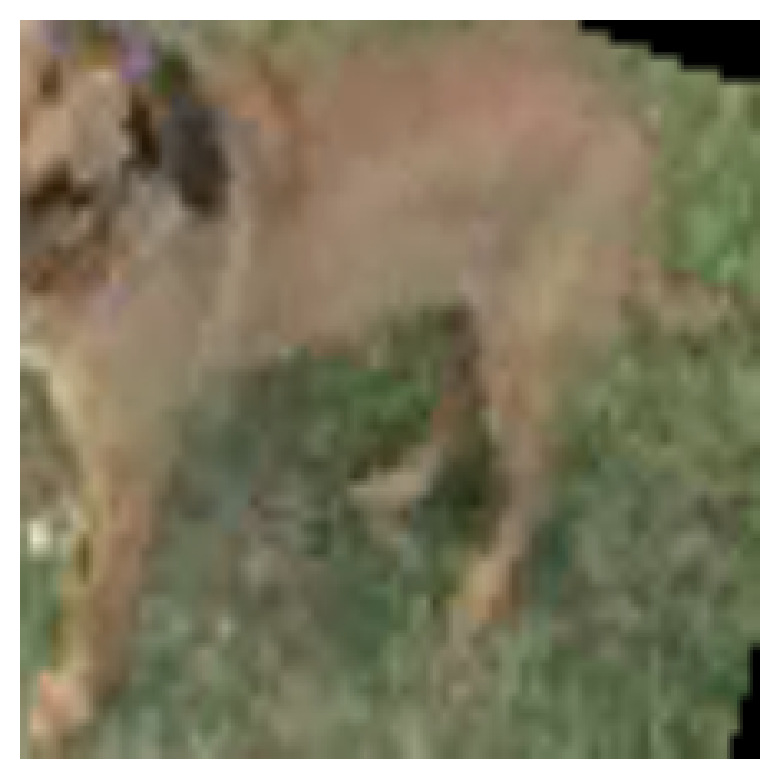

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    
    plt.imshow(np.clip(img, 0, 1))
    plt.axis('off')
    plt.show()

# 2. Récupération d'un batch d'images
images, labels = next(iter(trainloader))

# 3. Choix de l'index de l'image (Change le chiffre entre 0 et 31 pour voir d'autres animaux du batch !)
index_image = 5 

print(f"Affichage de l'image à l'index {index_image} (Classe : {'Chien' if labels[index_image].item() == 1 else 'Chat'})")
imshow(images[index_image])

In [7]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()
        
        # Bloc Convolutif 1 : Entrée 3 canaux (RGB) -> Sortie 32 canaux. Image 224x224
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Bloc Convolutif 2 : Entrée 32 -> Sortie 64. Image après MaxPool 1 = 112x112
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Bloc Convolutif 3 : Entrée 64 -> Sortie 128. Image après MaxPool 2 = 56x56
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Max Pooling (divise la taille spatiale par 2)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Couches de classification (Fully Connected)
        # Après 3 max poolings, l'image 224x224 passe à 112x112 -> 56x56 -> 28x28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.dropout = nn.Dropout(0.5) # Régularisation requise pour éviter le surapprentissage
        self.fc2 = nn.Linear(512, 2)   # 2 sorties : Chat ou Chien
        
    def forward(self, x):
        # Passage dans les 3 blocs Convolution + Batch Norm + ReLU + MaxPool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Aplatir le tenseur pour l'envoyer dans les couches Fully Connected
        x = x.view(-1, 128 * 28 * 28)
        
        # Classification finale
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Pas de Softmax ici, géré automatiquement par nn.CrossEntropyLoss
        return x

# Instanciation et envoi du modèle sur la puce MPS du Mac
model_scratch = CatDogCNN()
model_scratch.to(device)
print("[SUCCÈS] Modèle From Scratch créé et chargé sur l'appareil.")

[SUCCÈS] Modèle From Scratch créé et chargé sur l'appareil.


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, epochs=5, save_path="best_model.pth"):
    # Dictionnaires pour stocker l'historique des métriques
    history = {
        'train_loss': [], 'train_acc': [], 'train_prec': [], 'train_rec': [],
        'val_loss': [], 'val_acc': [], 'val_prec': [], 'val_rec': []
    }
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- PHASE D'ENTRAÎNEMENT ---
        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
        epoch_train_loss = running_loss / len(train_loader.sampler)
        epoch_train_acc = accuracy_score(all_labels, all_preds)
        epoch_train_prec = precision_score(all_labels, all_preds, average='binary', zero_division=0)
        epoch_train_rec = recall_score(all_labels, all_preds, average='binary', zero_division=0)
        
        # --- PHASE DE VALIDATION ---
        model.eval()
        running_val_loss = 0.0
        all_val_preds = []
        all_val_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader.sampler)
        epoch_val_acc = accuracy_score(all_val_labels, all_val_preds)
        epoch_val_prec = precision_score(all_val_labels, all_val_preds, average='binary', zero_division=0)
        epoch_val_rec = recall_score(all_val_labels, all_val_preds, average='binary', zero_division=0)
        
        # Sauvegarder les métriques dans l'historique
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['train_prec'].append(epoch_train_prec)
        history['train_rec'].append(epoch_train_rec)
        
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['val_prec'].append(epoch_val_prec)
        history['val_rec'].append(epoch_val_rec)
        
        # Affichage des résultats de l'époque
        print(f"Époque {epoch+1}/{epochs} -> "
              f"Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Prec: {epoch_train_prec:.4f} | Rec: {epoch_train_rec:.4f}")
        print(f"               Val Loss:   {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Prec: {epoch_val_prec:.4f} | Rec: {epoch_val_rec:.4f}")
        
        # Persistance locale : Sauvegarde automatique du meilleur modèle selon la Val Loss
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"      [SAUVEGARDE] Meilleur modèle enregistré sous '{save_path}'")
            
    return history

print("[SUCCÈS] Fonction d'entraînement générique initialisée.")

[SUCCÈS] Fonction d'entraînement générique initialisée.


In [9]:
# 1. Définition de la fonction de perte
criterion = nn.CrossEntropyLoss()

# 2. Définition du premier optimisateur (Expérience A : Adam)
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

# 3. Lancement officiel de l'entraînement de l'Expérience A
print("=== LANCEMENT DE L'ENTRAÎNEMENT : CNN FROM SCRATCH ===")
history_scratch = train_and_validate(
    model=model_scratch,
    train_loader=trainloader,
    val_loader=valloader,
    criterion=criterion,
    optimizer=optimizer_scratch,
    epochs=5,
    save_path="best_model_scratch.pth"
)

=== LANCEMENT DE L'ENTRAÎNEMENT : CNN FROM SCRATCH ===
Époque 1/5 -> Train Loss: 1.9378 | Acc: 0.5800 | Prec: 0.5923 | Rec: 0.5175
               Val Loss:   0.6085 | Acc: 0.6696 | Prec: 0.6700 | Rec: 0.6607
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_scratch.pth'
Époque 2/5 -> Train Loss: 0.6415 | Acc: 0.6245 | Prec: 0.6468 | Rec: 0.5509
               Val Loss:   0.5876 | Acc: 0.6807 | Prec: 0.7217 | Rec: 0.5820
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_scratch.pth'
Époque 3/5 -> Train Loss: 0.6334 | Acc: 0.6268 | Prec: 0.6648 | Rec: 0.5138
               Val Loss:   0.5923 | Acc: 0.6847 | Prec: 0.6946 | Rec: 0.6527
Époque 4/5 -> Train Loss: 0.6338 | Acc: 0.6243 | Prec: 0.6815 | Rec: 0.4689
               Val Loss:   0.5990 | Acc: 0.6749 | Prec: 0.6400 | Rec: 0.7908
Époque 5/5 -> Train Loss: 0.6381 | Acc: 0.6280 | Prec: 0.6994 | Rec: 0.4509
               Val Loss:   0.6124 | Acc: 0.6831 | Prec: 0.7345 | Rec: 0.5677


In [10]:
import urllib.request
import ssl
from torchvision import models
import torch
from torch import nn

# Étape 1 : Désactivation globale et agressive de la vérification SSL
context = ssl._create_unverified_context()
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
urllib.request.install_opener(opener)
torch.hub._validate_not_a_forked_repo = lambda *args, **kwargs: None # Évite les conflits de requêtes

print("Initialisation de l'architecture ResNet18 (locale)...")
# On crée le modèle vide (sans poids) pour éviter que la fonction native ne déclenche l'erreur SSL
model_transfer = models.resnet18(weights=None)

# Étape 2 : Téléchargement forcé des poids officiels via l'URL directe avec le bypass SSL activé
print("Téléchargement forcé des poids d'origine...")
url_weights = "https://download.pytorch.org/models/resnet18-f37072fd.pth"

# Téléchargement sécurisé manuel vers le cache de PyTorch
state_dict = torch.hub.load_state_dict_from_url(url_weights, progress=True, map_location='cpu')
model_transfer.load_state_dict(state_dict)
print("Poids pré-entraînés appliqués avec succès !")

# Étape 3 : Congélation des couches (Transfer Learning standard)
for param in model_transfer.parameters():
    param.requires_grad = False

# Étape 4 : Adaptation de la dernière couche linéaire pour tes 2 classes (Chats et Chiens)
num_ftrs = model_transfer.fc.in_features
model_transfer.fc = nn.Linear(num_ftrs, 2)

# Envoi sur la puce graphique
model_transfer.to(device)
print(f"\n[SUCCÈS RAPIDE] Modèle ResNet18 prêt et configuré sur : {device}")

Initialisation de l'architecture ResNet18 (locale)...
Téléchargement forcé des poids d'origine...
Poids pré-entraînés appliqués avec succès !

[SUCCÈS RAPIDE] Modèle ResNet18 prêt et configuré sur : mps


In [11]:
import torch.optim as optim

# 1. Définition de l'optimiseur SGD (uniquement sur la couche fc finale modifiée)
optimizer_transfer = optim.SGD(model_transfer.fc.parameters(), lr=0.001, momentum=0.9)

# 2. Lancement officiel de l'entraînement de l'Expérience B
print("=== LANCEMENT DE L'ENTRAÎNEMENT : TRANSFER LEARNING (RESNET18) ===")
history_transfer = train_and_validate(
    model=model_transfer,
    train_loader=trainloader,
    val_loader=valloader,
    criterion=criterion,
    optimizer=optimizer_transfer,
    epochs=5,
    save_path="best_model_transfer.pth"
)

=== LANCEMENT DE L'ENTRAÎNEMENT : TRANSFER LEARNING (RESNET18) ===
Époque 1/5 -> Train Loss: 0.2317 | Acc: 0.9047 | Prec: 0.9092 | Rec: 0.8995
               Val Loss:   0.0768 | Acc: 0.9744 | Prec: 0.9699 | Rec: 0.9790
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 2/5 -> Train Loss: 0.1789 | Acc: 0.9222 | Prec: 0.9279 | Rec: 0.9158
               Val Loss:   0.0663 | Acc: 0.9796 | Prec: 0.9864 | Rec: 0.9723
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 3/5 -> Train Loss: 0.1695 | Acc: 0.9276 | Prec: 0.9351 | Rec: 0.9192
               Val Loss:   0.0571 | Acc: 0.9809 | Prec: 0.9799 | Rec: 0.9817
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 4/5 -> Train Loss: 0.1597 | Acc: 0.9315 | Prec: 0.9338 | Rec: 0.9291
               Val Loss:   0.0565 | Acc: 0.9802 | Prec: 0.9833 | Rec: 0.9768
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 5/5 ->

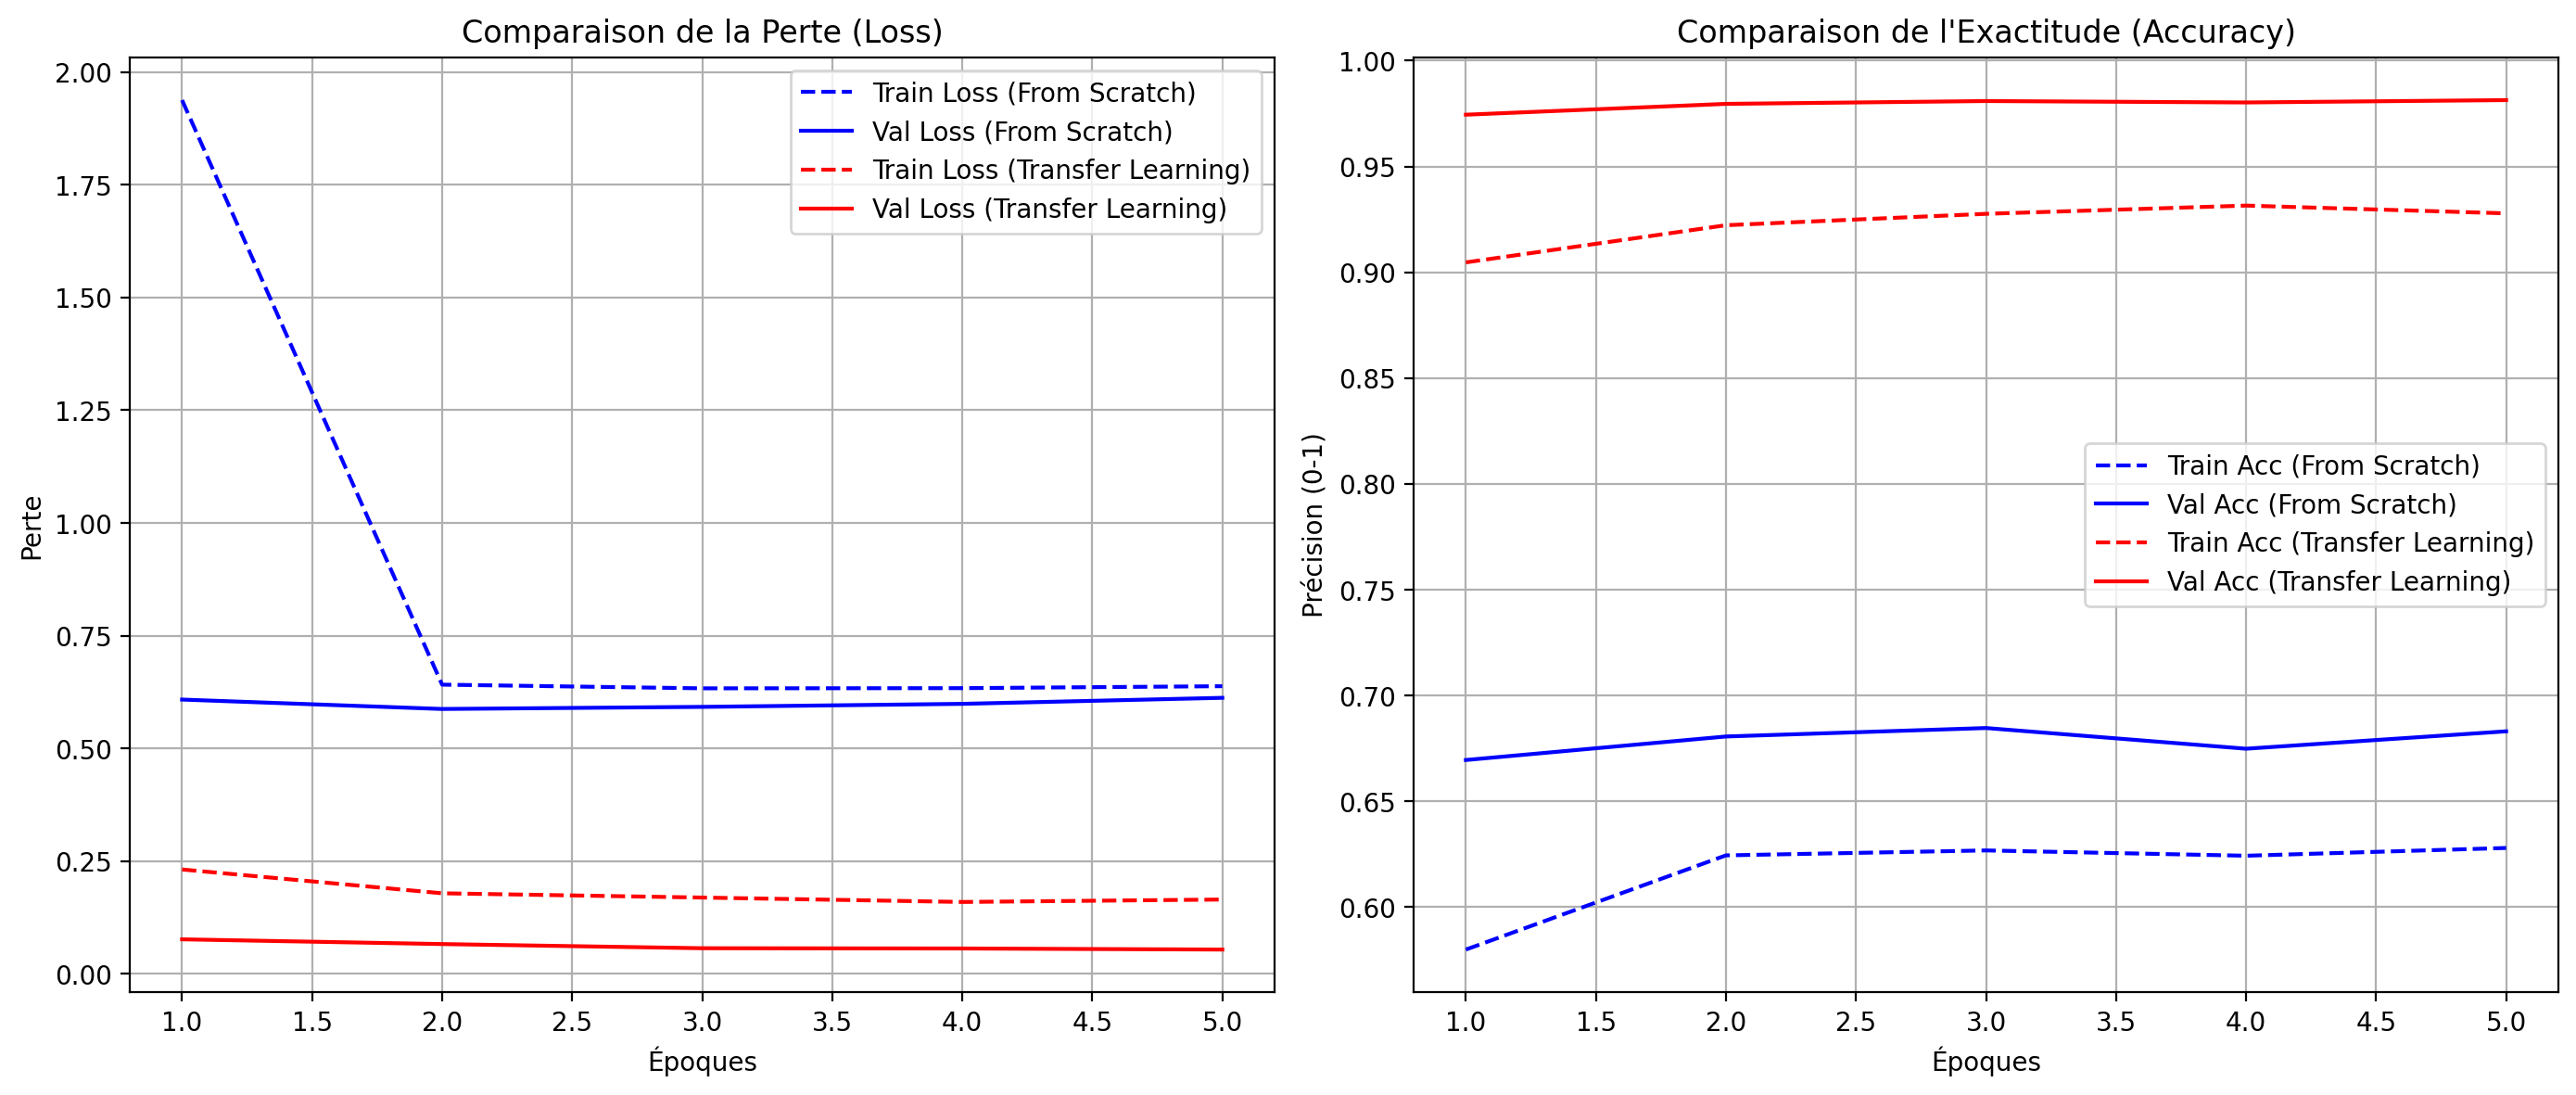

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, 6)

plt.figure(figsize=(14, 6))

# 1. Graphique des Pertes (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_scratch['train_loss'], 'b--', label='Train Loss (From Scratch)')
plt.plot(epochs_range, history_scratch['val_loss'], 'b-', label='Val Loss (From Scratch)')
plt.plot(epochs_range, history_transfer['train_loss'], 'r--', label='Train Loss (Transfer Learning)')
plt.plot(epochs_range, history_transfer['val_loss'], 'r-', label='Val Loss (Transfer Learning)')
plt.title('Comparaison de la Perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

# 2. Graphique de l'Exactitude (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_scratch['train_acc'], 'b--', label='Train Acc (From Scratch)')
plt.plot(epochs_range, history_scratch['val_acc'], 'b-', label='Val Acc (From Scratch)')
plt.plot(epochs_range, history_transfer['train_acc'], 'r--', label='Train Acc (Transfer Learning)')
plt.plot(epochs_range, history_transfer['val_acc'], 'r-', label='Val Acc (Transfer Learning)')
plt.title("Comparaison de l'Exactitude (Accuracy)")
plt.xlabel('Époques')
plt.ylabel('Précision (0-1)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Rechargement du meilleur modèle pour le test
model_transfer.load_state_dict(torch.load("best_model_transfer.pth", map_location=device))
model_transfer.eval()

print(" Modèle réimporté localement avec succès. Prêt pour les inférences sur le jeu de test.")

 Modèle réimporté localement avec succès. Prêt pour les inférences sur le jeu de test.


## Experience C : comparaison de deux optimiseurs sur le CNN from scratch

Pour satisfaire l'exigence "au moins deux optimiseurs", on reentraine exactement la meme architecture CatDogCNN, cette fois avec SGD (momentum), puis on la compare a la version Adam de l'Experience A. La comparaison est faite a configuration egale (meme seed, memes donnees, meme nombre d'epoques) afin d'isoler l'effet de l'optimiseur.

In [14]:
# Experience C : meme CNN from scratch, mais optimiseur SGD
# On refixe le seed pour repartir du meme point que l'Experience A (comparaison equitable)
set_seed(42)

model_scratch_sgd = CatDogCNN()
model_scratch_sgd.to(device)

# SGD avec un learning rate un peu plus eleve, adapte a cet optimiseur
optimizer_scratch_sgd = optim.SGD(model_scratch_sgd.parameters(), lr=0.01, momentum=0.9)

print("=== ENTRAINEMENT : CNN FROM SCRATCH (SGD) ===")
history_scratch_sgd = train_and_validate(
    model=model_scratch_sgd,
    train_loader=trainloader,
    val_loader=valloader,
    criterion=criterion,
    optimizer=optimizer_scratch_sgd,
    epochs=5,
    save_path="best_model_scratch_sgd.pth"
)

=== ENTRAINEMENT : CNN FROM SCRATCH (SGD) ===
Époque 1/5 -> Train Loss: 0.7298 | Acc: 0.5254 | Prec: 0.5227 | Rec: 0.6011
               Val Loss:   0.6922 | Acc: 0.5029 | Prec: 0.0000 | Rec: 0.0000
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_scratch_sgd.pth'
Époque 2/5 -> Train Loss: 0.6935 | Acc: 0.5056 | Prec: 0.5070 | Rec: 0.4594
               Val Loss:   0.6940 | Acc: 0.4971 | Prec: 0.4971 | Rec: 1.0000
Époque 3/5 -> Train Loss: 0.6934 | Acc: 0.5004 | Prec: 0.5010 | Rec: 0.5835
               Val Loss:   0.6932 | Acc: 0.5027 | Prec: 0.0000 | Rec: 0.0000
Époque 4/5 -> Train Loss: 0.6934 | Acc: 0.4987 | Prec: 0.4994 | Rec: 0.5434
               Val Loss:   0.6932 | Acc: 0.4973 | Prec: 0.4972 | Rec: 1.0000
Époque 5/5 -> Train Loss: 0.6934 | Acc: 0.4995 | Prec: 0.5002 | Rec: 0.5905
               Val Loss:   0.6934 | Acc: 0.4971 | Prec: 0.4971 | Rec: 1.0000


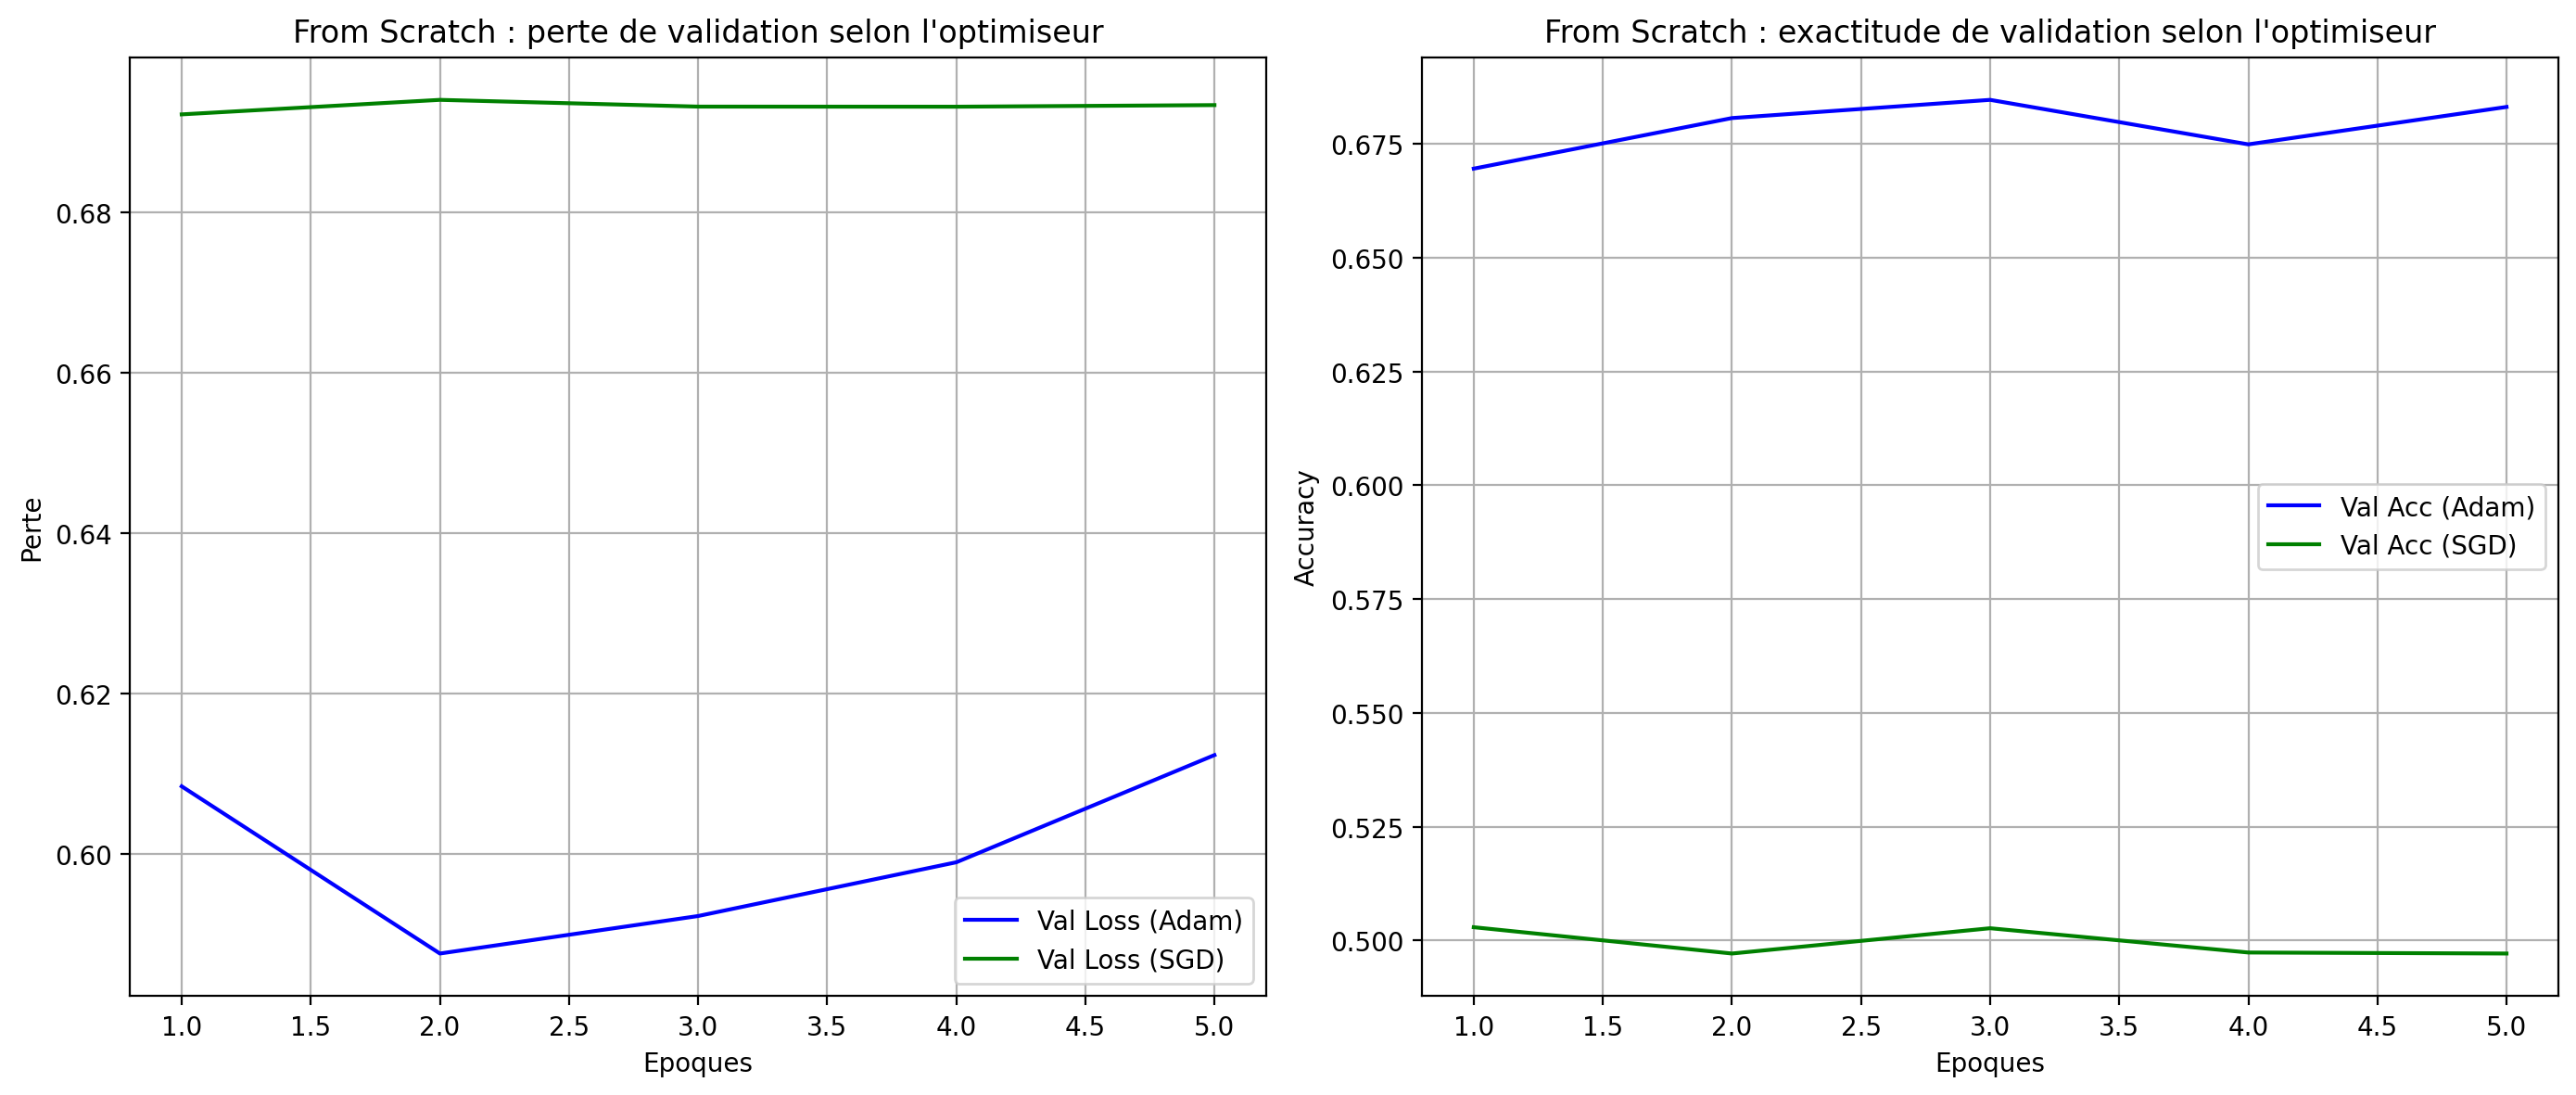

In [15]:
# Comparaison des deux optimiseurs sur le CNN from scratch (Adam vs SGD)
epochs_range = range(1, 6)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_scratch['val_loss'], 'b-', label='Val Loss (Adam)')
plt.plot(epochs_range, history_scratch_sgd['val_loss'], 'g-', label='Val Loss (SGD)')
plt.title("From Scratch : perte de validation selon l'optimiseur")
plt.xlabel('Epoques')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_scratch['val_acc'], 'b-', label='Val Acc (Adam)')
plt.plot(epochs_range, history_scratch_sgd['val_acc'], 'g-', label='Val Acc (SGD)')
plt.title("From Scratch : exactitude de validation selon l'optimiseur")
plt.xlabel('Epoques')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Analyse a completer apres execution : comparer la vitesse de convergence et la stabilite des deux optimiseurs. En pratique, Adam converge plus vite en debut d'entrainement, tandis que SGD avec momentum peut offrir une meilleure generalisation lorsque le learning rate est bien regle. Reporter les valeurs finales dans le tableau du README.

## Evaluation finale sur le jeu de test (point obligatoire 6)

On recharge les meilleurs modeles sauvegardes (selon la val loss) puis on les evalue sur le jeu de test, qui n'a jamais servi a l'entrainement. On calcule accuracy, precision et recall, et on trace les matrices de confusion (bonus).

=== RESULTATS SUR LE JEU DE TEST (donnees inedites) ===

From Scratch (Adam)        : Accuracy 0.6700 | Precision 0.7202 | Recall 0.5560
From Scratch (SGD)         : Accuracy 0.5000 | Precision 0.0000 | Recall 0.0000
Transfer Learning (SGD)    : Accuracy 0.9748 | Precision 0.9837 | Recall 0.9656

--- Lignes a copier dans le tableau Test du README ---
| From Scratch (Adam) | 67.00% | 0.7202 | 0.5560 |
| From Scratch (SGD) | 50.00% | 0.0000 | 0.0000 |
| Transfer Learning (SGD) | 97.48% | 0.9837 | 0.9656 |


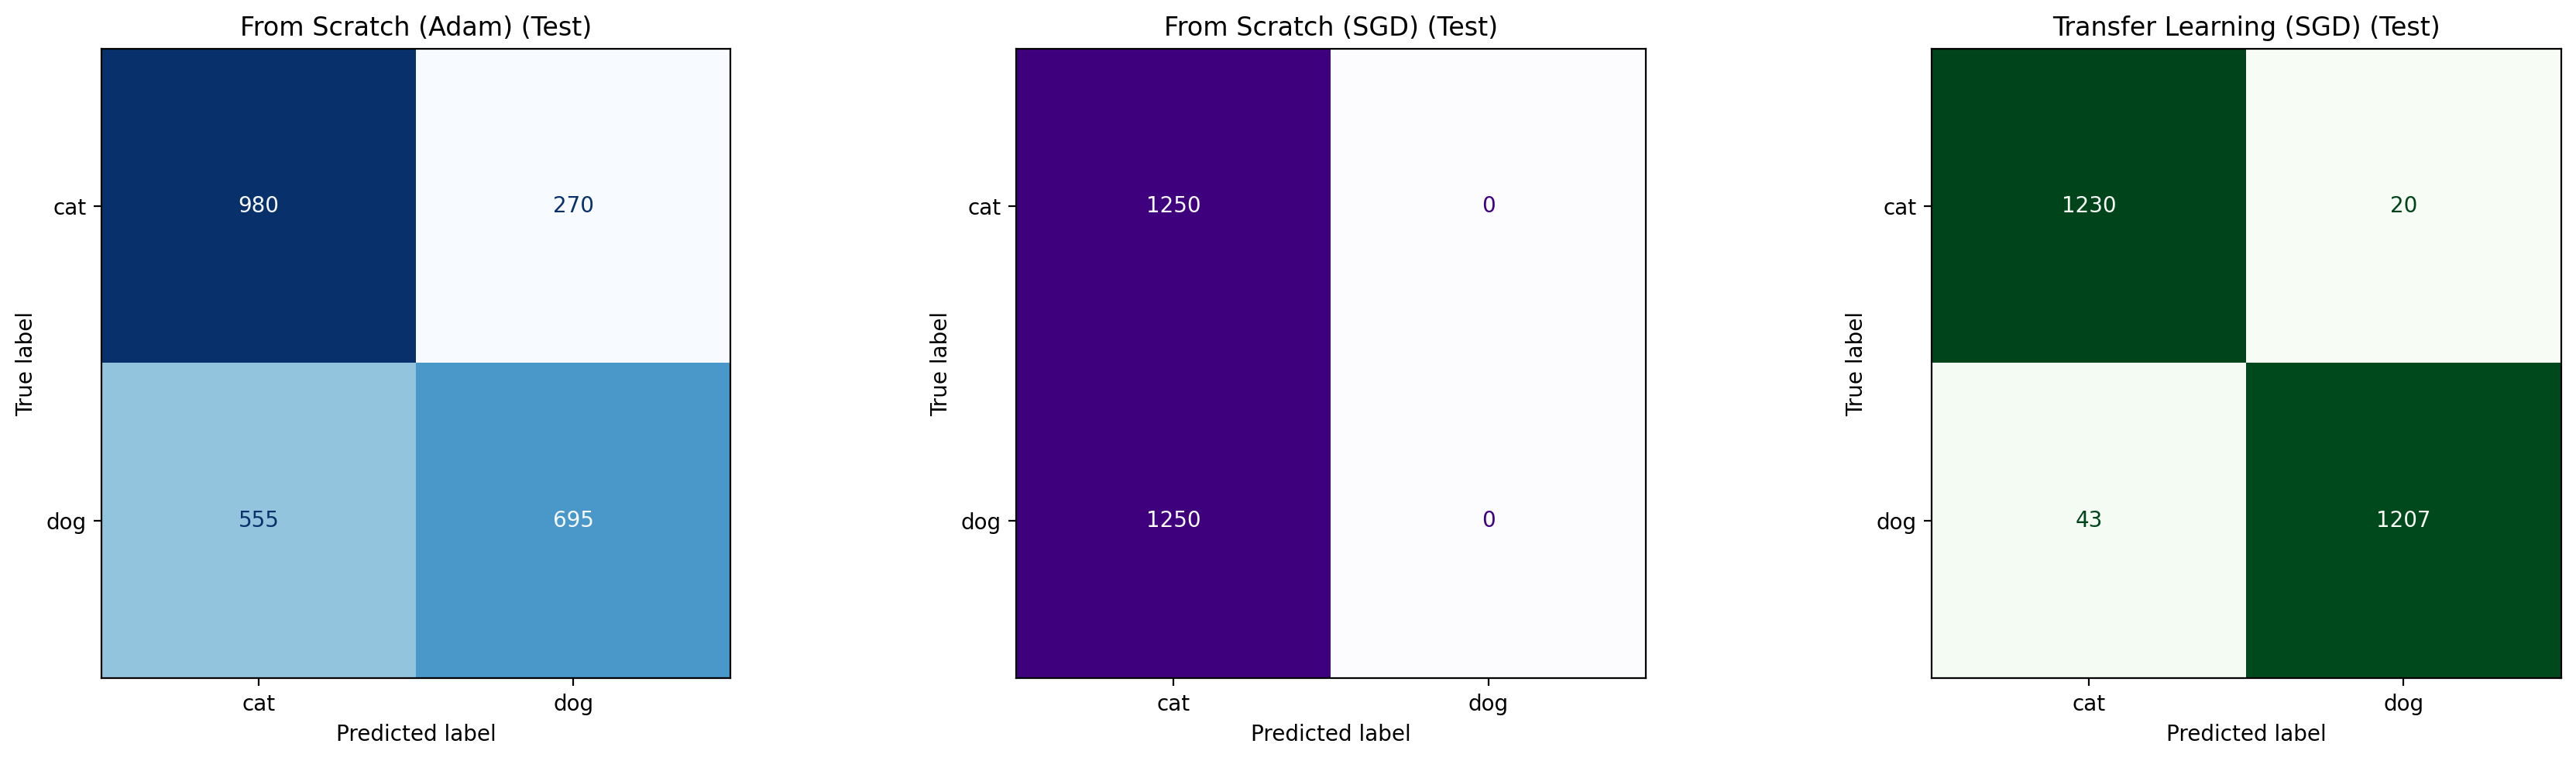

In [16]:
# Evaluation finale sur le jeu de test
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Ordre des classes defini par ImageFolder (ordre alphabetique) : cat=0, dog=1
class_names = test_dataset.classes


def evaluate_on_test(model, checkpoint_path, loader, device):
    """Recharge les poids sauvegardes puis evalue le modele sur le jeu de test."""
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, prec, rec, cm


experiments = [
    ("From Scratch (Adam)", model_scratch, "best_model_scratch.pth"),
    ("From Scratch (SGD)", model_scratch_sgd, "best_model_scratch_sgd.pth"),
    ("Transfer Learning (SGD)", model_transfer, "best_model_transfer.pth"),
]

results = []
print("=== RESULTATS SUR LE JEU DE TEST (donnees inedites) ===\n")
for name, model, ckpt in experiments:
    acc, prec, rec, cm = evaluate_on_test(model, ckpt, testloader, device)
    results.append((name, acc, prec, rec, cm))
    print(f"{name:26s} : Accuracy {acc:.4f} | Precision {prec:.4f} | Recall {rec:.4f}")

print("\n--- Lignes a copier dans le tableau Test du README ---")
for name, acc, prec, rec, cm in results:
    print(f"| {name} | {acc*100:.2f}% | {prec:.4f} | {rec:.4f} |")

# Matrices de confusion
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]
cmaps = ["Blues", "Purples", "Greens"]
for ax, (name, acc, prec, rec, cm), cmap in zip(axes, results, cmaps):
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name + " (Test)")
plt.tight_layout()
plt.show()